In [1]:
import torch
print(torch.cuda.is_available())

True


Dataset과 DataLoader

In [2]:
# Dataset 불러오기

# TorchVision에서 Fashion-MNIST 데이터셋 불러오기
# Zalando의 기사 이미지 데이터셋: 60,000개의 학습 예제, 10,000개의 테스트 예제
# 다음 매개변수들을 활용
#       root: 학습/테스트 데이터
#       train: 학습용 또는 테스트용 데이터셋 여부 지정
#       download=True: root의 데이터가 없는 경우 인터넷에서 다운로드합니다
#       transform / target_transform: 특징과,정답 변형을 지정

import torch
# torch.utils.data: 데이터를 다루는 도구 모음
# 그 중 Dataset class 가져옴: 데이터 하나하나에 어떻게 접근할지 정의하는 추상 클래스
from torch.utils.data import Dataset
# torch의 비전용 library 그 중 datasets는 데이터셋 가져오는 용도
from torchvision import datasets
# torchvision.transforms는 이미지 변형을 위한 라이브러리
# 그 중 ToTensor는 1. PIL 이미지나 NumPy 배열을 PyTorch 텐서로 변환
#                 2. 픽셀 값을 0~255 정수 범위에서 0.0~1.0 실수 범위로 정규화
from torchvision.transforms import ToTensor
# PyTorch와 무관한 시각화 라이브러리; 그래프나 이미지를 화면에 그릴 때 쓰는 파이썬의 대표적인 도구
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = 'data',              # working dire 아래에 data라는 폴더 만들고 거기에 저장
    train = True,               # training용 데이터를 가져오겠다
    download = True,            # 없으면 다운로드
    transform = ToTensor()      # 위에서 말한 ToTensor 기능을 default로 지정
)

test_data = datasets.FashionMNIST(
    root = 'data',              
    train = False,              # test용 데이터를 가져오겠다
    download = True,
    transform = ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.32MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.4MB/s]


<function matplotlib.pyplot.show(close=None, block=None)>

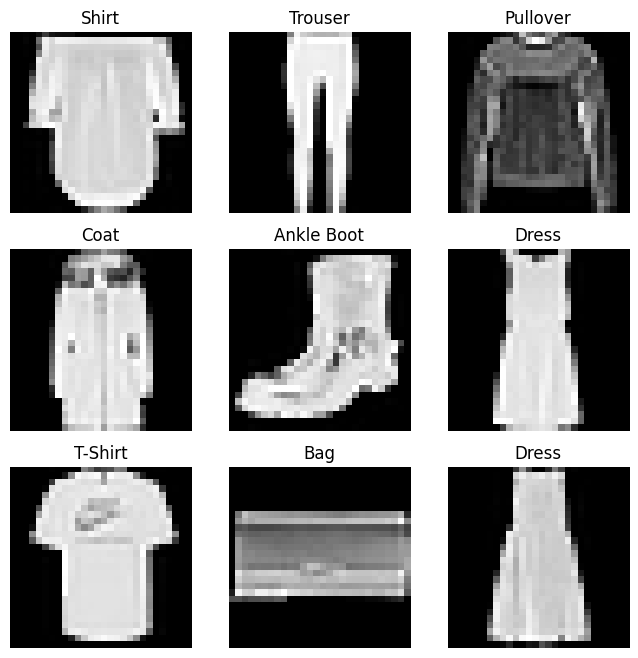

In [3]:
# Dataset을 순회하고 시각화하기
# Dataset에 list처럼 직접 접근할 수 있음

# labels_map : datasets에 존재하는 정수 label을 단어로 바꾸기 위한 맵
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize = (8,8)) # 8x8(inch) 캔버스 만들기
cols, rows = 3, 3 # 캔버스를 3x3 격자구조로 쓰기 위한 변수 선언

for i in range(1, cols * rows + 1):
    # len(training_data) 만큼의 정수 중 무작위로 size가 (1,)인 텐서 생성 후 .item() 으로 숫자로 변환
    sample_idx = torch.randint(len(training_data), size=(1,)).item() 
    # img, label을 둘 다 뽑음
    img, label = training_data[sample_idx]
    # 캔버스에 배치
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    # squeeze는 크기가 1인 차원 제거
    # FashionMNIST는 (1,28,28) 
    # plt.imshow는 흑백이므로 2차원 데이터만 기대함
    plt.imshow(img.squeeze(), cmap="gray")

plt.show

In [4]:
# 파일에서 사용자 정의 데이터셋 만들기

# 사용자 정의 Dataseet 클래스는 반드시 3개 함수를 구현해야 함
#       __init__, __len__, __getitem__

import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform = None, target_transform = None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
    
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        sample = {"image": image, "label": label}
        return sample



In [13]:
# DataLoader로 학습용 데이터 준비하기

# Dataset은 데이터셋의 feature를 가져오고 label을 지정하는 일을 함
# DataLoader는 이러한 set을 학습을 위해 minibatch, epoch마다 데이터 섞기 등을 수행하는 객체

from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size = 64, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = 64, shuffle = True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])

train_features[0] dimension: torch.Size([1, 28, 28])
train_features[0] dimension(after squeeze): torch.Size([28, 28])


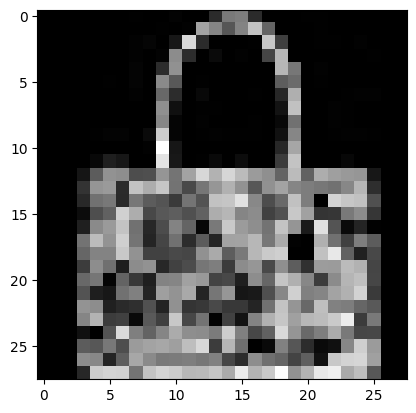

Label: 8


In [15]:
# DataLoader를 통해 순회하기(iterate)

# 아래의 각 iteration은 batch만큼의 feature & label의 묶음을 반환함
# suffle = True로 지정했으므로 모든 배치 순회 후 데이터 섞임

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

print(f"\ntrain_features[0] dimension: {train_features[0].size()}")
img = train_features[0].squeeze()
print(f"train_features[0] dimension(after squeeze): {img.size()}")

label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")